In [484]:
import pandas as pd
import plotly.express as px
import numpy as np
#from geopy.geocoders import Nominatim
wm = pd.read_csv("./World-cup-matches.csv")

In [485]:
wm

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,1930-07-13 15:00:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444.0,3,0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX
1,1930,1930-07-13 15:00:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346.0,2,0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL
2,1930,1930-07-14 12:45:00,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059.0,2,0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA
3,1930,1930-07-14 14:50:00,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,2549.0,1,0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER
4,1930,1930-07-15 16:00:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,23409.0,0,0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,2014,2014-07-05 17:00:00,Quarter-finals,Arena Fonte Nova,Salvador,Netherlands,0,0,Costa Rica,Netherlands win on penalties (4 - 3),51179.0,0,0,Ravshan IRMATOV (UZB),RASULOV Abduxamidullo (UZB),KOCHKAROV Bakhadyr (KGZ),255953,300186488,NED,CRC
848,2014,2014-07-08 17:00:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,1,7,Germany,,58141.0,0,5,RODRIGUEZ Marco (MEX),TORRENTERA Marvin (MEX),QUINTERO Marcos (MEX),255955,300186474,BRA,GER
849,2014,2014-07-09 17:00:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Netherlands,0,0,Argentina,Argentina win on penalties (2 - 4),63267.0,0,0,C�neyt �AKIR (TUR),DURAN Bahattin (TUR),ONGUN Tarik (TUR),255955,300186490,NED,ARG
850,2014,2014-07-12 17:00:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,0,3,Netherlands,,68034.0,0,2,HAIMOUDI Djamel (ALG),ACHIK Redouane (MAR),ETCHIALI Abdelhak (ALG),255957,300186502,BRA,NED


In [486]:
wm.info()

<class 'pandas.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  852 non-null    int64  
 1   Datetime              852 non-null    str    
 2   Stage                 852 non-null    str    
 3   Stadium               852 non-null    str    
 4   City                  852 non-null    str    
 5   Home Team Name        852 non-null    str    
 6   Home Team Goals       852 non-null    int64  
 7   Away Team Goals       852 non-null    int64  
 8   Away Team Name        852 non-null    str    
 9   Win conditions        852 non-null    str    
 10  Attendance            850 non-null    float64
 11  Half-time Home Goals  852 non-null    int64  
 12  Half-time Away Goals  852 non-null    int64  
 13  Referee               852 non-null    str    
 14  Assistant 1           852 non-null    str    
 15  Assistant 2           852 non-null

In [487]:
# Adding/renaming columns to better answer future questions
wm.insert(8, "Total Goals", wm["Home Team Goals"]+wm["Away Team Goals"])
wm.insert(9, "Winning Score", np.maximum(wm["Home Team Goals"], wm["Away Team Goals"]))
wm.insert(10, "Losing Score", np.minimum(wm["Home Team Goals"], wm["Away Team Goals"]))
wm["Referee"] = wm["Referee"].str[-4:-1]
wm["Assistant 1"] = wm["Assistant 1"].str[-4:-1]
wm["Assistant 2"] = wm["Assistant 2"].str[-4:-1]
mask = wm["Home Team Name"].str.startswith("rn")
wm.loc[mask, "Home Team Name"] = wm.loc[mask, "Home Team Name"].str[4:]
mask = wm["Away Team Name"].str.startswith("rn")
wm.loc[mask, "Away Team Name"] = wm.loc[mask, "Away Team Name"].str[4:]
wm

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Total Goals,Winning Score,...,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,1930-07-13 15:00:00,Group 1,Pocitos,Montevideo,France,4,1,5,4,...,4444.0,3,0,URU,BEL,BRA,201,1096,FRA,MEX
1,1930,1930-07-13 15:00:00,Group 4,Parque Central,Montevideo,USA,3,0,3,3,...,18346.0,2,0,ARG,URU,CHI,201,1090,USA,BEL
2,1930,1930-07-14 12:45:00,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,3,2,...,24059.0,2,0,URU,URU,FRA,201,1093,YUG,BRA
3,1930,1930-07-14 14:50:00,Group 3,Pocitos,Montevideo,Romania,3,1,4,3,...,2549.0,1,0,CHI,BEL,URU,201,1098,ROU,PER
4,1930,1930-07-15 16:00:00,Group 1,Parque Central,Montevideo,Argentina,1,0,1,1,...,23409.0,0,0,BRA,BOL,ROU,201,1085,ARG,FRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,2014,2014-07-05 17:00:00,Quarter-finals,Arena Fonte Nova,Salvador,Netherlands,0,0,0,0,...,51179.0,0,0,UZB,UZB,KGZ,255953,300186488,NED,CRC
848,2014,2014-07-08 17:00:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,1,7,8,7,...,58141.0,0,5,MEX,MEX,MEX,255955,300186474,BRA,GER
849,2014,2014-07-09 17:00:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Netherlands,0,0,0,0,...,63267.0,0,0,TUR,TUR,TUR,255955,300186490,NED,ARG
850,2014,2014-07-12 17:00:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,0,3,3,3,...,68034.0,0,2,ALG,MAR,ALG,255957,300186502,BRA,NED


In [488]:
# Potential Q's:
# 1. Scores change over time?
# 2. Relation between refs and wins?
# 3. Can predict loser's score from winner's (more often high-scoring or dominating)?
# 4. Host country success?
# 5. Most common score?
# 6. Pre- vs. post-half time score differences?
# 7. Attendance over time?
# 8. Attendance affects total score (higher tentions)?
# 9. Average total score changes during tournament?
# 10. Total goals by team?
# 11. 

In [489]:
#1. Over time, are more goals being scored or fewer?
wmi = wm.groupby("Year")[["Total Goals"]].mean().reset_index()
wmi

,Year,Total Goals
0,1930,3.888889
1,1934,4.117647
2,1938,4.666667
3,1950,4.000000
4,1954,5.384615
5,1958,3.600000
6,1962,2.781250
7,1966,2.781250
8,1970,2.968750
9,1974,2.552632


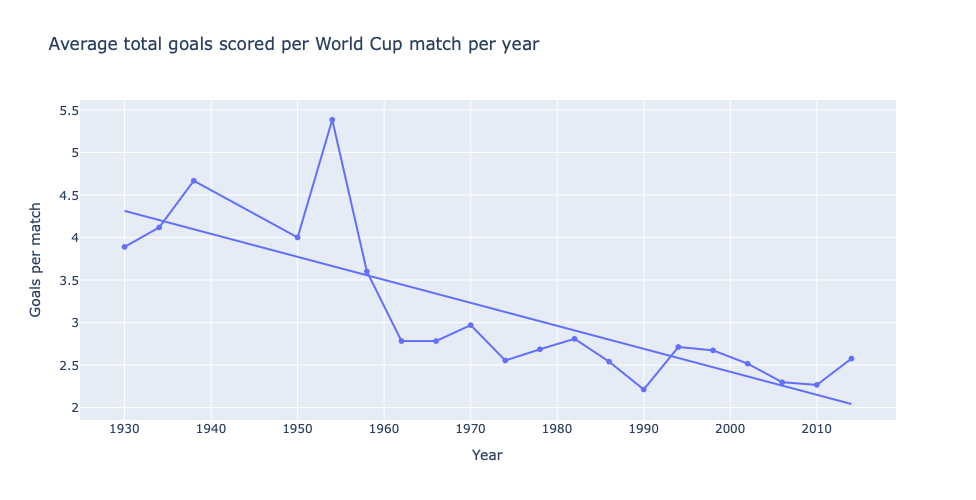

In [510]:
fig = px.scatter(data_frame = wmi,
              x = "Year",
              y = "Total Goals",
              #markers = True,
              title = "Average total goals scored per World Cup match per year",
              labels = {"Total Goals":"Goals per match"},
              height = 500,
              width = 900,
             trendline = "ols")
fig.update_traces(mode="lines+markers", selector=dict(mode="markers"))
fig

In [491]:
# 2. Are some countries' refs more lenient than others?
wmii = wm.copy()
wmii["Referee"] = wm["Referee"].str[-4:-1]
wmii["Assistant 1"] = wm["Assistant 1"].str[-4:-1]
wmii["Assistant 2"] = wm["Assistant 2"].str[-4:-1]
wmii

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Total Goals,Winning Score,...,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,1930-07-13 15:00:00,Group 1,Pocitos,Montevideo,France,4,1,5,4,...,4444.0,3,0,UR,BE,BR,201,1096,FRA,MEX
1,1930,1930-07-13 15:00:00,Group 4,Parque Central,Montevideo,USA,3,0,3,3,...,18346.0,2,0,AR,UR,CH,201,1090,USA,BEL
2,1930,1930-07-14 12:45:00,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,3,2,...,24059.0,2,0,UR,UR,FR,201,1093,YUG,BRA
3,1930,1930-07-14 14:50:00,Group 3,Pocitos,Montevideo,Romania,3,1,4,3,...,2549.0,1,0,CH,BE,UR,201,1098,ROU,PER
4,1930,1930-07-15 16:00:00,Group 1,Parque Central,Montevideo,Argentina,1,0,1,1,...,23409.0,0,0,BR,BO,RO,201,1085,ARG,FRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,2014,2014-07-05 17:00:00,Quarter-finals,Arena Fonte Nova,Salvador,Netherlands,0,0,0,0,...,51179.0,0,0,UZ,UZ,KG,255953,300186488,NED,CRC
848,2014,2014-07-08 17:00:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,1,7,8,7,...,58141.0,0,5,ME,ME,ME,255955,300186474,BRA,GER
849,2014,2014-07-09 17:00:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Netherlands,0,0,0,0,...,63267.0,0,0,TU,TU,TU,255955,300186490,NED,ARG
850,2014,2014-07-12 17:00:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,0,3,3,3,...,68034.0,0,2,AL,MA,AL,255957,300186502,BRA,NED


In [492]:
# Find average total goals scored in matches officiated by each team's referees
wmii = wm.groupby("Referee")[["Total Goals"]].mean().reset_index()
wmii

,Referee,Total Goals
0,ALG,3.142857
1,ARG,2.257143
2,AUS,2.416667
3,AUT,2.789474
4,BEL,2.321429
...,...,...
78,USA,2.923077
79,UZB,2.100000
80,VEN,4.000000
81,WAL,3.818182


In [493]:
# Find only teams that have refereed at least 30 games
referees = wm["Referee"].value_counts()
referees.head(10)

Referee
ITA    52
ENG    45
MEX    41
FRA    40
BRA    36
ARG    35
GER    35
SUI    34
ESP    33
BEL    28
Name: count, dtype: int64

In [494]:
# Create data frame for figure
referees = referees[referees >= 30].index
wmii = wmii[wmii["Referee"].isin(referees)].sort_values("Total Goals")
wmii

,Referee,Total Goals
28,GER,1.971429
1,ARG,2.257143
8,BRA,2.861111
44,MEX,3.024390
36,ITA,3.076923
24,FRA,3.150000
21,ESP,3.151515
66,SUI,3.352941
20,ENG,3.622222


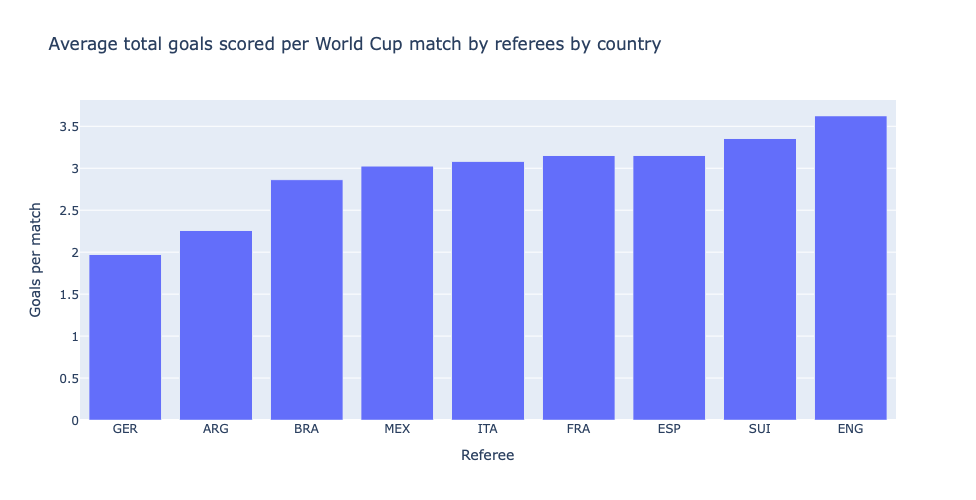

In [495]:
fig = px.bar(data_frame = wmii,
             x = "Referee",
             y = "Total Goals",
             title = "Average total goals scored per World Cup match by referees by country",
             labels = {"Total Goals":"Goals per match"},
             height = 500,
             width = 900
            )
fig

In [496]:
# 3. Loser's score vs. winner's score
# Create pivot table for data
wmiii = wm.pivot_table(values = "Year", index = "Home Team Goals", columns = "Away Team Goals", aggfunc = "count", observed = True)
wmiii

Away Team Goals,0,1,2,3,4,5,7
Home Team Goals,,,,,,,
0,72.0,53.0,29.0,18.0,4.0,NaN,1.0
1,108.0,82.0,30.0,15.0,6.0,3.0,2.0
2,62.0,101.0,30.0,9.0,1.0,2.0,NaN
3,32.0,49.0,30.0,4.0,1.0,NaN,NaN
4,20.0,22.0,14.0,1.0,2.0,NaN,NaN
5,6.0,4.0,6.0,1.0,NaN,NaN,NaN
6,5.0,9.0,NaN,2.0,NaN,1.0,NaN
7,3.0,2.0,1.0,1.0,NaN,1.0,NaN
8,3.0,NaN,NaN,1.0,NaN,NaN,NaN


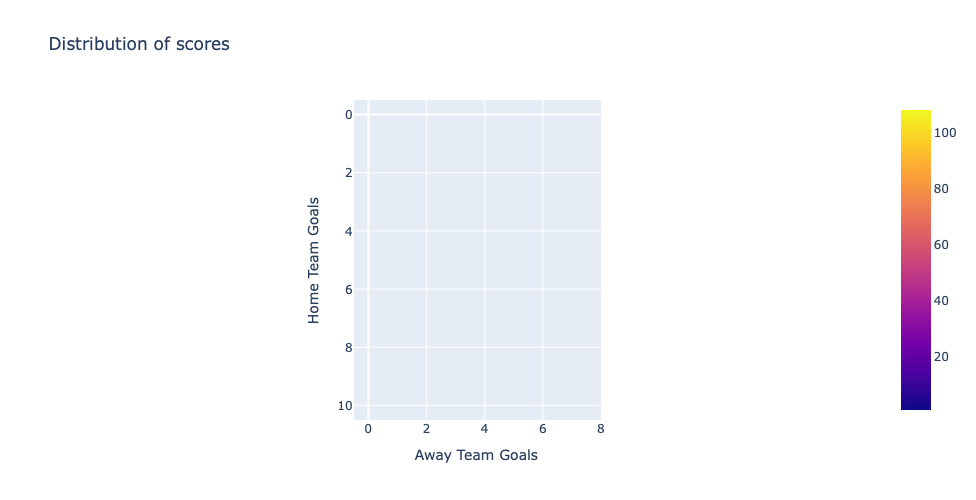

In [497]:
fig = px.imshow(wmiii,
               title = "Distribution of scores",
               height = 500,
               width = 900)
fig

In [498]:
# 4. 
wm

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Total Goals,Winning Score,...,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,1930-07-13 15:00:00,Group 1,Pocitos,Montevideo,France,4,1,5,4,...,4444.0,3,0,URU,BEL,BRA,201,1096,FRA,MEX
1,1930,1930-07-13 15:00:00,Group 4,Parque Central,Montevideo,USA,3,0,3,3,...,18346.0,2,0,ARG,URU,CHI,201,1090,USA,BEL
2,1930,1930-07-14 12:45:00,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,3,2,...,24059.0,2,0,URU,URU,FRA,201,1093,YUG,BRA
3,1930,1930-07-14 14:50:00,Group 3,Pocitos,Montevideo,Romania,3,1,4,3,...,2549.0,1,0,CHI,BEL,URU,201,1098,ROU,PER
4,1930,1930-07-15 16:00:00,Group 1,Parque Central,Montevideo,Argentina,1,0,1,1,...,23409.0,0,0,BRA,BOL,ROU,201,1085,ARG,FRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,2014,2014-07-05 17:00:00,Quarter-finals,Arena Fonte Nova,Salvador,Netherlands,0,0,0,0,...,51179.0,0,0,UZB,UZB,KGZ,255953,300186488,NED,CRC
848,2014,2014-07-08 17:00:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,1,7,8,7,...,58141.0,0,5,MEX,MEX,MEX,255955,300186474,BRA,GER
849,2014,2014-07-09 17:00:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Netherlands,0,0,0,0,...,63267.0,0,0,TUR,TUR,TUR,255955,300186490,NED,ARG
850,2014,2014-07-12 17:00:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,0,3,3,3,...,68034.0,0,2,ALG,MAR,ALG,255957,300186502,BRA,NED


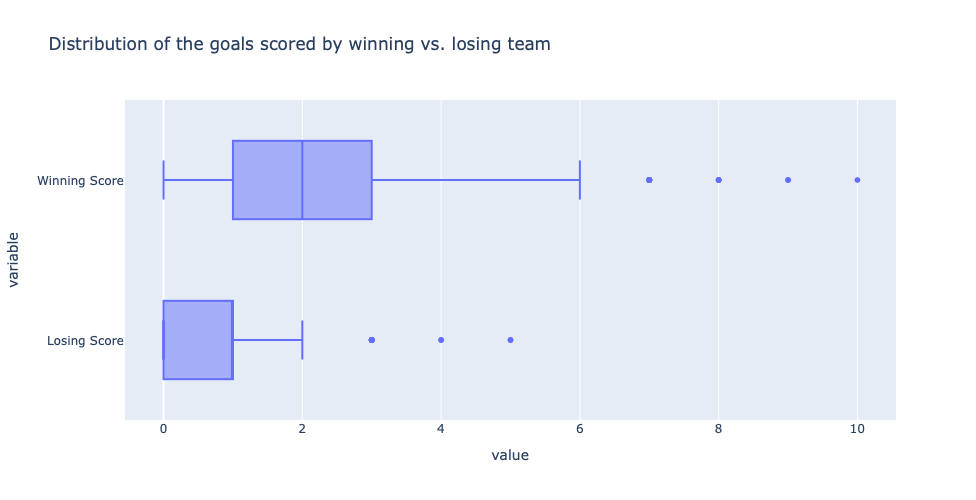

In [499]:
fig = px.box(data_frame = wm,
             title = "Distribution of the goals scored by winning vs. losing team",
             x = ["Losing Score", "Winning Score"],
            #color = "season",
             #labels = {"value":"Goals", "variable":""},
             height = 500,
             width = 900
            )
fig.show()

In [500]:
# 5. Attendance through time by stage
wmv = wm.groupby(["Year", "Stage"])["Attendance"].mean().reset_index()
wmv

,Year,Stage,Attendance
0,1930,Final,68346.000000
1,1930,Group 1,20443.500000
2,1930,Group 2,22610.333333
3,1930,Group 3,43435.333333
4,1930,Group 4,16217.333333
...,...,...,...
179,2014,Group H,51943.666667
180,2014,Play-off for third place,68034.000000
181,2014,Quarter-finals,63578.000000
182,2014,Round of 16,59134.428571


In [501]:
# Obtain acceptable stages
wmv = wmv[(wmv["Stage"] == "Final") |
    (wmv["Stage"] == "Semi-finals") |
    (wmv["Stage"] == "Match for third place") |
    (wmv["Stage"] == "Quarter-finals") |
    (wmv["Stage"] == "Round of 16")]
wmv

,Year,Stage,Attendance
0,1930,Final,68346.000000
5,1930,Semi-finals,76376.500000
6,1934,Final,55000.000000
7,1934,Match for third place,7000.000000
9,1934,Quarter-finals,23200.000000
...,...,...,...
170,2010,Semi-finals,61719.500000
171,2014,Final,74738.000000
181,2014,Quarter-finals,63578.000000
182,2014,Round of 16,59134.428571


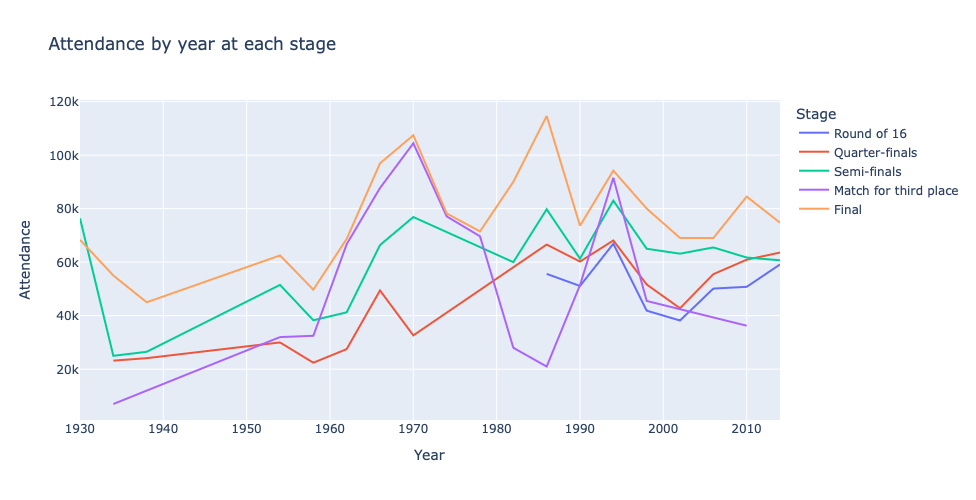

In [502]:
fig = px.line(data_frame = wmv,
              x = "Year",
              y = "Attendance",
              color = "Stage",
              title = "Attendance by year at each stage",
              category_orders = {"Stage": ["Round of 16", "Quarter-finals", "Semi-finals", "Match for third place", "Final"]},
              height = 500,
              width = 900)
fig

In [503]:
# 6. Does the number of people in attendance affect how many goals are scored?
wmvi = wm[(wm["Stage"] == "Final") |
    (wm["Stage"] == "Semi-finals") |
    (wm["Stage"] == "Match for third place") |
    (wm["Stage"] == "Quarter-finals") |
    (wm["Stage"] == "Round of 16")]
wmvi

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Total Goals,Winning Score,...,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
15,1930,1930-07-26 14:45:00,Semi-finals,Estadio Centenario,Montevideo,Argentina,6,1,7,6,...,72886.0,1,0,BEL,MEX,CHI,202,1088,ARG,USA
16,1930,1930-07-27 14:45:00,Semi-finals,Estadio Centenario,Montevideo,Uruguay,6,1,7,6,...,79867.0,3,1,BRA,BOL,FRA,202,1101,URU,YUG
17,1930,1930-07-30 14:15:00,Final,Estadio Centenario,Montevideo,Uruguay,4,2,6,4,...,68346.0,1,2,BEL,BOL,BEL,405,1087,URU,ARG
26,1934,1934-05-31 16:30:00,Quarter-finals,Stadio Benito Mussolini,Turin,Czechoslovakia,3,2,5,3,...,12000.0,1,1,AUT,EGY,FRA,418,1143,TCH,SUI
27,1934,1934-05-31 16:30:00,Quarter-finals,San Siro,Milan,Germany,2,1,3,2,...,3000.0,0,0,ITA,SUI,NED,418,1129,GER,SWE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,2014,2014-07-05 13:00:00,Quarter-finals,Estadio Nacional,Brasilia,Argentina,1,0,1,1,...,68551.0,1,0,ITA,ITA,ITA,255953,300186504,ARG,BEL
847,2014,2014-07-05 17:00:00,Quarter-finals,Arena Fonte Nova,Salvador,Netherlands,0,0,0,0,...,51179.0,0,0,UZB,UZB,KGZ,255953,300186488,NED,CRC
848,2014,2014-07-08 17:00:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,1,7,8,7,...,58141.0,0,5,MEX,MEX,MEX,255955,300186474,BRA,GER
849,2014,2014-07-09 17:00:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Netherlands,0,0,0,0,...,63267.0,0,0,TUR,TUR,TUR,255955,300186490,NED,ARG


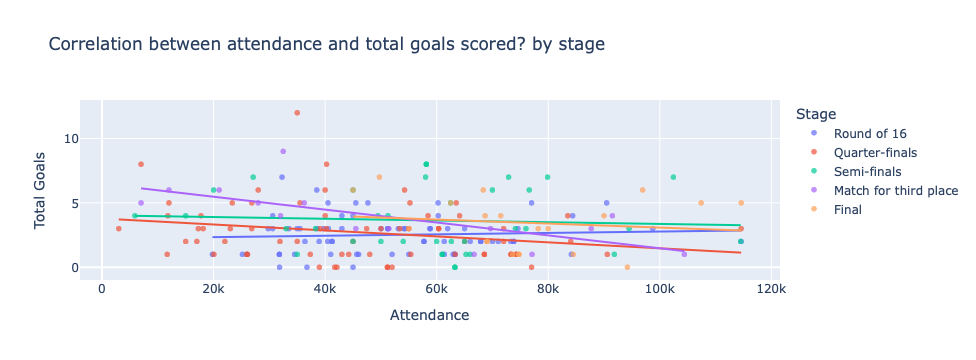

In [504]:
fig = px.scatter(data_frame = wmvi,
                 x = "Attendance",
                 y = "Total Goals",
                 color = "Stage",
                 opacity = .7,
                 title = "Correlation between attendance and total goals scored? by stage",
                 category_orders = {"Stage": ["Round of 16", "Quarter-finals", "Semi-finals", "Match for third place", "Final"]},
                 trendline = "ols")
fig

In [505]:
# 7. Who's scored the most?
wm["Home Team Name"] = wm["Home Team Name"].replace({"Germany FR": "Germany"})
wm["Away Team Name"] = wm["Away Team Name"].replace({"Germany FR": "Germany"})
wmviih = wm.groupby("Home Team Name")["Home Team Goals"].sum()
wmviia = wm.groupby("Away Team Name")["Away Team Goals"].sum()
wmvii = wmviih.add(wmviia, fill_value=0).sort_values(ascending=False)
wmvii = wmvii.to_frame(name = "goals").reset_index()
wmvii = wmvii.iloc[:8]
wmvii

,Home Team Name,goals
0,Germany,235.0
1,Brazil,225.0
2,Argentina,133.0
3,Italy,128.0
4,France,108.0
5,Spain,92.0
6,Netherlands,91.0
7,Hungary,87.0


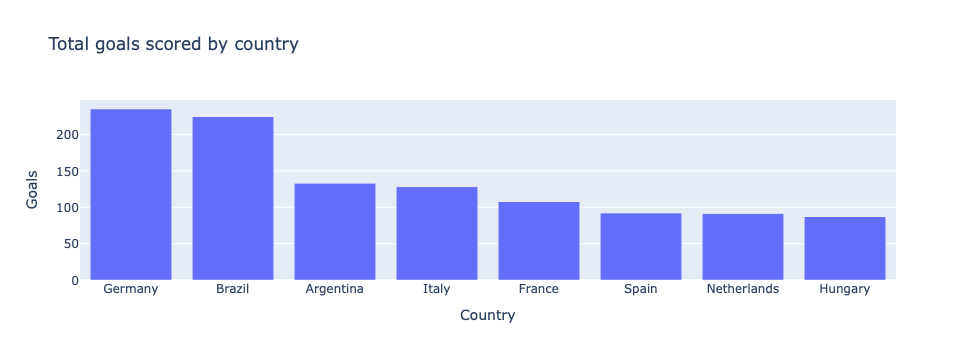

In [506]:
fig = px.bar(data_frame = wmvii,
             x = "Home Team Name",
             y = "goals",
             title = "Total goals scored by country",
             labels = {"Home Team Name":"Country", "goals":"Goals"})
fig